# In-depth EDA: cleaned listings\n\nRuns on `sale_only_model_cleaned_listings.csv` (ETL output — sale-only, outlier-trimmed, RERA-merged, pre-one-hot). Price/leakage columns (`Price_Cr`, `PricePerSqft`) are excluded from anything framed as a predictor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW = "../raw"
df = pd.read_csv(f"{RAW}/sale_only_model_cleaned_listings.csv", low_memory=False)
df.shape

(32158, 34)

## Price distribution — raw vs log

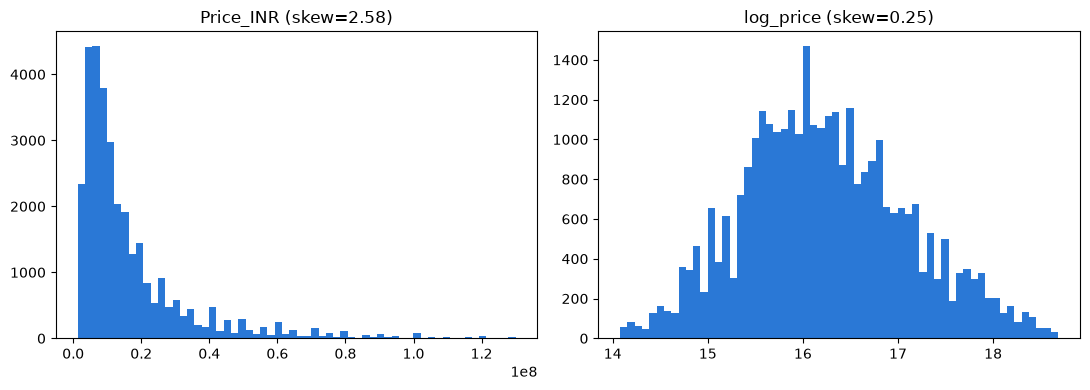

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(df["Price_INR"], bins=60, color="#2a78d6")
axes[0].set_title(f"Price_INR (skew={df['Price_INR'].skew():.2f})")
axes[1].hist(df["log_price"], bins=60, color="#2a78d6")
axes[1].set_title(f"log_price (skew={df['log_price'].skew():.2f})")
plt.tight_layout()

## Price vs area, by BHK

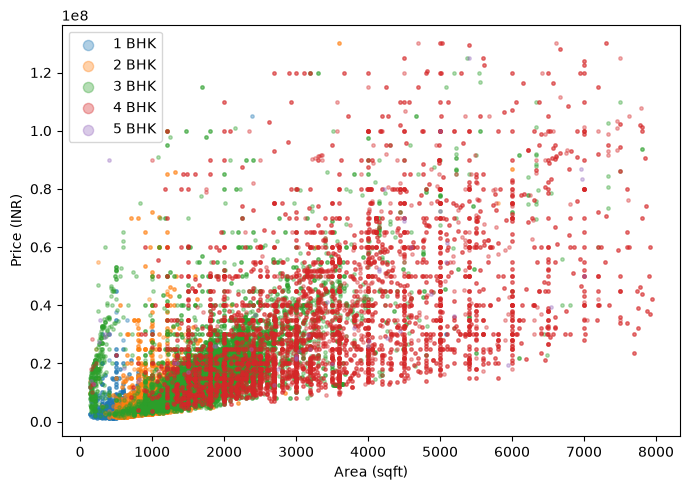

In [3]:
fig, ax = plt.subplots(figsize=(7,5))
for bhk, sub in df[df["BHK"].between(1,5)].groupby("BHK"):
    ax.scatter(sub["Area_Sqft"], sub["Price_INR"], s=6, alpha=0.35, label=f"{int(bhk)} BHK")
ax.set_xlabel("Area (sqft)")
ax.set_ylabel("Price (INR)")
ax.legend(markerscale=3)
plt.tight_layout()

## Correlation heatmap (numeric features vs price)

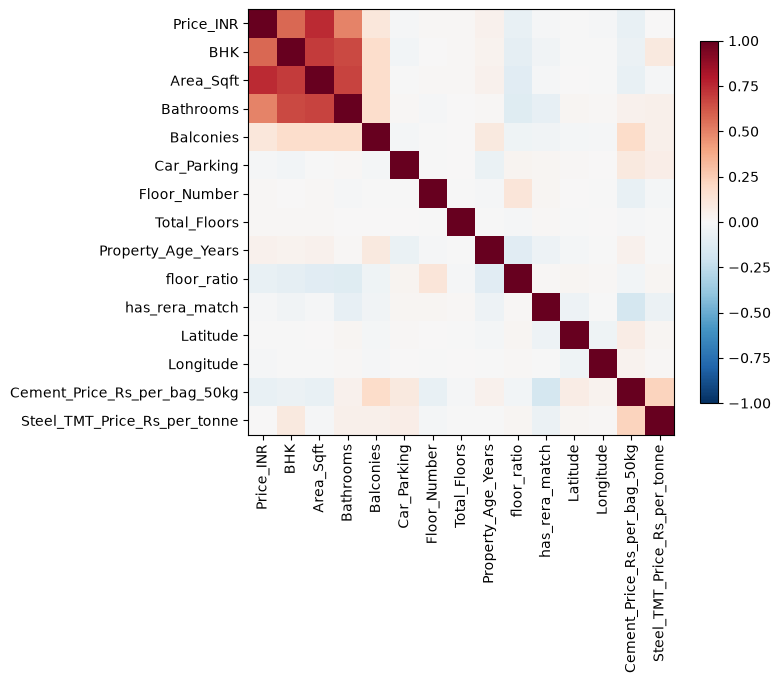

In [4]:
num_cols = ["Price_INR","BHK","Area_Sqft","Bathrooms","Balconies","Car_Parking",
            "Floor_Number","Total_Floors","Property_Age_Years","floor_ratio",
            "has_rera_match","Latitude","Longitude",
            "Cement_Price_Rs_per_bag_50kg","Steel_TMT_Price_Rs_per_tonne"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
fig.colorbar(im, shrink=0.8)
plt.tight_layout()

## Price per sqft by construction status

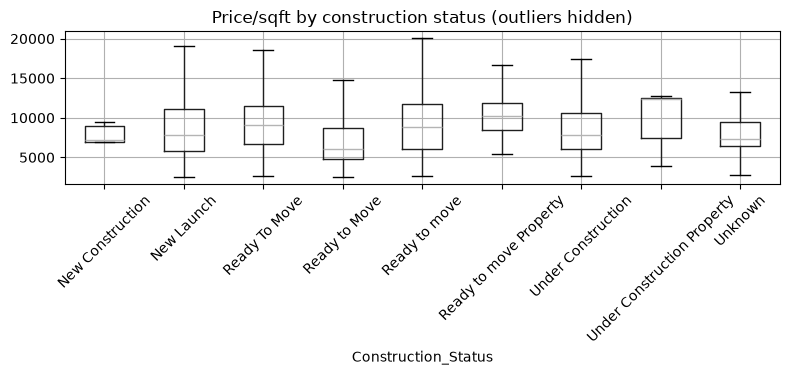

In [5]:
order = df.groupby("Construction_Status")["PricePerSqft"].median().sort_values(ascending=False).index
df.boxplot(column="PricePerSqft", by="Construction_Status", figsize=(8,4), rot=45,
           showfliers=False, positions=range(len(order)))
plt.suptitle("")
plt.title("Price/sqft by construction status (outliers hidden)")
plt.tight_layout()

## Geospatial: price per sqft across Hyderabad

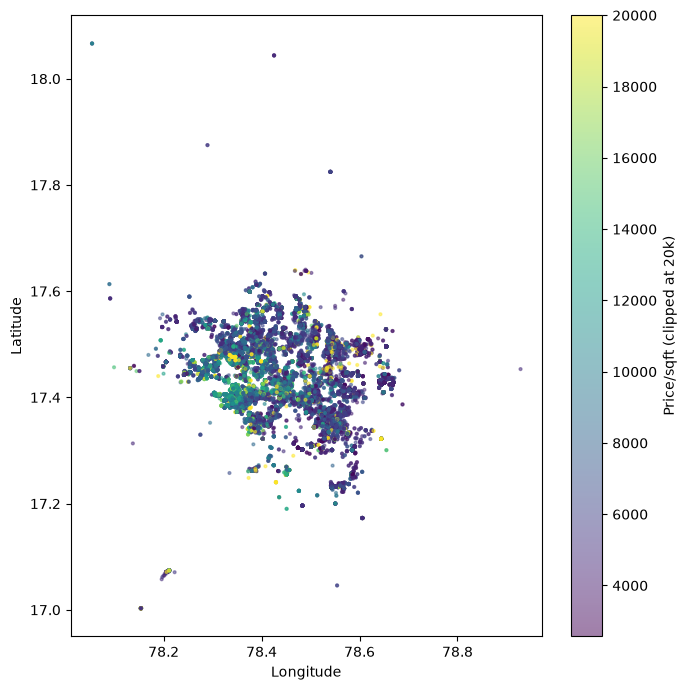

In [6]:
geo = df[df["Latitude"].between(17,18.5) & df["Longitude"].between(78,79)]
fig, ax = plt.subplots(figsize=(7,7))
sc = ax.scatter(geo["Longitude"], geo["Latitude"], c=geo["PricePerSqft"].clip(upper=20000),
                 cmap="viridis", s=4, alpha=0.5)
fig.colorbar(sc, label="Price/sqft (clipped at 20k)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()

## RERA match rate by district

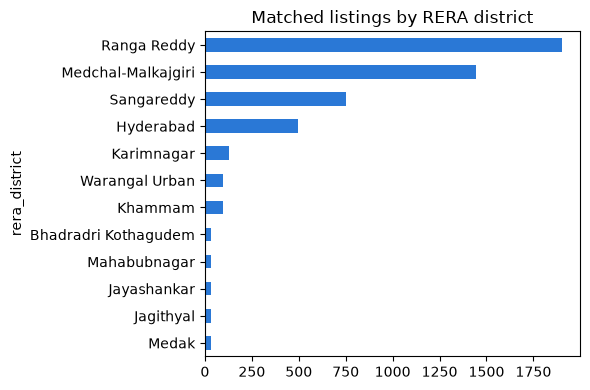

In [7]:
matched = df[df["has_rera_match"]==1]
matched["rera_district"].value_counts().head(12).plot.barh(figsize=(6,4), color="#2a78d6")
plt.title("Matched listings by RERA district")
plt.gca().invert_yaxis()
plt.tight_layout()

## Statistical summary

In [8]:
from scipy import stats
print("Price_INR: skew=%.2f kurtosis=%.2f" % (df["Price_INR"].skew(), df["Price_INR"].kurt()))
print("log_price: skew=%.2f kurtosis=%.2f" % (df["log_price"].skew(), df["log_price"].kurt()))
shapiro_n = min(len(df), 5000)
stat, p = stats.shapiro(df["log_price"].sample(shapiro_n, random_state=1))
print(f"Shapiro-Wilk on log_price (n={shapiro_n}): stat={stat:.4f} p={p:.4g}")

Price_INR: skew=2.58 kurtosis=8.17
log_price: skew=0.25 kurtosis=-0.27
Shapiro-Wilk on log_price (n=5000): stat=0.9916 p=1.335e-16


**Notes**\n\n- `log_price` is far closer to normal than raw `Price_INR` (skew near 0 vs strongly right-skewed) — regress on `log_price`, not `Price_INR`, for a linear model.\n- RERA match coverage concentrates in a handful of districts (Ranga Reddy, Medchal-Malkajgiri) — match rate should not be assumed uniform across the city.